<a href="https://colab.research.google.com/github/analubreide/SSD---Tarefa-2/blob/main/MVP_Risco_Custo_Tempo_Unidade_Dados_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Risco, Custo e Tempo de Implantação de uma Nova Unidade de Controle de Dados

**Aluna:** Ana Luisa Breide Pessôa Guerra
**Matrícula:** 231013289
**Disciplina:** Sistemas de Suporte à Decisão

---

Este notebook constrói um **modelo de apoio à decisão (MVP)** para avaliar a implantação de uma nova unidade de controle de dados (data center / data control unit), a partir da base pública do Kaggle **"Green AI Data Center Telemetry"**.

O modelo combina três dimensões de decisão:

1. **Risco operacional** — eficiência energética (PUE), emissão de carbono, temperatura de operação, eficiência de resfriamento e instabilidade (outliers).
2. **Custo computacional** — estimado a partir de um modelo de *Machine Learning* (Random Forest) treinado sobre os dados reais de telemetria.
3. **Tempo de implantação** — estimado por um modelo heurístico transparente (parâmetros explícitos), combinado com o risco e o custo de cada configuração.

As três dimensões são então combinadas em uma **Matriz de Decisão Multicritério (MCDA)**, com análise de sensibilidade dos pesos e simulação de Monte Carlo para medir a robustez da recomendação final.


## 1. Configuração do Ambiente

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 20)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Ambiente configurado com sucesso.')


Ambiente configurado com sucesso.


## 2. Carregamento da Base de Dados

A base utilizada é a **Green AI Data Center Telemetry** (Kaggle), contendo 10.000 registros sintéticos de telemetria de servidores em diferentes tipos de data center.

> ⚠️ **Atenção:** a coluna `datacenter_region` contém o valor literal `"NA"` (North America). Por padrão, o `pandas` interpreta essa string como valor ausente — por isso o carregamento abaixo desativa esse comportamento (`keep_default_na=False`).

Faça o upload do arquivo `green_ai_datacenter.csv` quando solicitado (ou ajuste o caminho caso já esteja no seu Google Drive).

In [2]:
from google.colab import files
import io, os

CSV_PATH = 'green_ai_datacenter.csv'

if not os.path.exists(CSV_PATH):
    print('Faça upload do arquivo green_ai_datacenter.csv (obtido do Kaggle):')
    uploaded = files.upload()
    CSV_PATH = list(uploaded.keys())[0]

df = pd.read_csv(CSV_PATH, keep_default_na=False, na_values=[''])
print(f'Base carregada: {df.shape[0]} linhas x {df.shape[1]} colunas')
df.head()


Faça upload do arquivo green_ai_datacenter.csv (obtido do Kaggle):


Saving green_ai_datacenter.csv to green_ai_datacenter.csv
Base carregada: 10000 linhas x 15 colunas


,server_type,cooling_type,datacenter_region,time_of_day,workload_intensity,cpu_utilization,memory_utilization,network_throughput_gbps,inlet_temperature_c,cooling_efficiency,power_consumption_kw,carbon_emission_kg,compute_cost_usd,pue,energy_efficiency_class
0,Compute,Air,APAC,Off-Peak,0.369,31.054,60.041,18.391,24.524,0.883,58.524,34.783,3.788,1.594,Low
1,Edge,Air,NA,Off-Peak,0.185,34.425,57.542,8.076,21.944,0.951,59.946,21.333,6.735,1.473,Medium
2,GPU,Air,NA,Night,0.214,17.188,32.198,5.057,19.726,0.961,139.775,58.925,16.039,1.619,Low
3,Storage,Liquid,EU,Peak,0.263,29.659,58.685,12.704,20.036,0.959,76.223,19.714,14.194,1.454,Medium
4,Compute,Air,EU,Off-Peak,0.283,23.086,50.790,18.460,25.290,0.923,102.655,25.609,18.259,1.394,High


In [3]:
# Verificação de qualidade dos dados
print('Tipos de dados:')
print(df.dtypes)
print()
print('Valores ausentes por coluna:')
print(df.isna().sum())
print()
print('Linhas duplicadas:', df.duplicated().sum())
print()
print('Categorias por variável categórica:')
for c in ['server_type', 'cooling_type', 'datacenter_region', 'time_of_day', 'energy_efficiency_class']:
    print(f'  {c}: {sorted(df[c].unique())}')


Tipos de dados:
server_type                 object
cooling_type                object
datacenter_region           object
time_of_day                 object
workload_intensity         float64
cpu_utilization            float64
memory_utilization         float64
network_throughput_gbps    float64
inlet_temperature_c        float64
cooling_efficiency         float64
power_consumption_kw       float64
carbon_emission_kg         float64
compute_cost_usd           float64
pue                        float64
energy_efficiency_class     object
dtype: object

Valores ausentes por coluna:
server_type                0
cooling_type               0
datacenter_region          0
time_of_day                0
workload_intensity         0
cpu_utilization            0
memory_utilization         0
network_throughput_gbps    0
inlet_temperature_c        0
cooling_efficiency         0
power_consumption_kw       0
carbon_emission_kg         0
compute_cost_usd           0
pue                        0
energy_ef

## 3. Análise Exploratória de Dados (EDA)

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
workload_intensity,10000.0,0.547172,0.260356,0.100,0.32000,0.5440,0.77525,1.000
cpu_utilization,10000.0,46.334781,19.409384,0.129,30.25325,46.3980,62.69175,91.754
memory_utilization,10000.0,65.723253,15.756341,5.000,54.99475,65.9430,76.74550,98.000
network_throughput_gbps,10000.0,15.469944,7.449646,1.756,10.24875,14.1170,19.34050,60.748
inlet_temperature_c,10000.0,22.034012,3.916553,15.000,19.34000,21.9105,24.48975,37.992
cooling_efficiency,10000.0,0.860706,0.095780,0.517,0.79600,0.8700,0.93600,1.000
power_consumption_kw,10000.0,82.091960,26.630186,28.169,64.18650,77.9000,95.79850,233.630
carbon_emission_kg,10000.0,33.122753,15.396742,5.069,21.86675,30.0285,41.38350,136.022
compute_cost_usd,10000.0,10.131131,4.975471,1.084,6.52975,9.3290,12.91575,42.053
pue,10000.0,1.480539,0.203365,1.050,1.35000,1.4690,1.59500,2.596


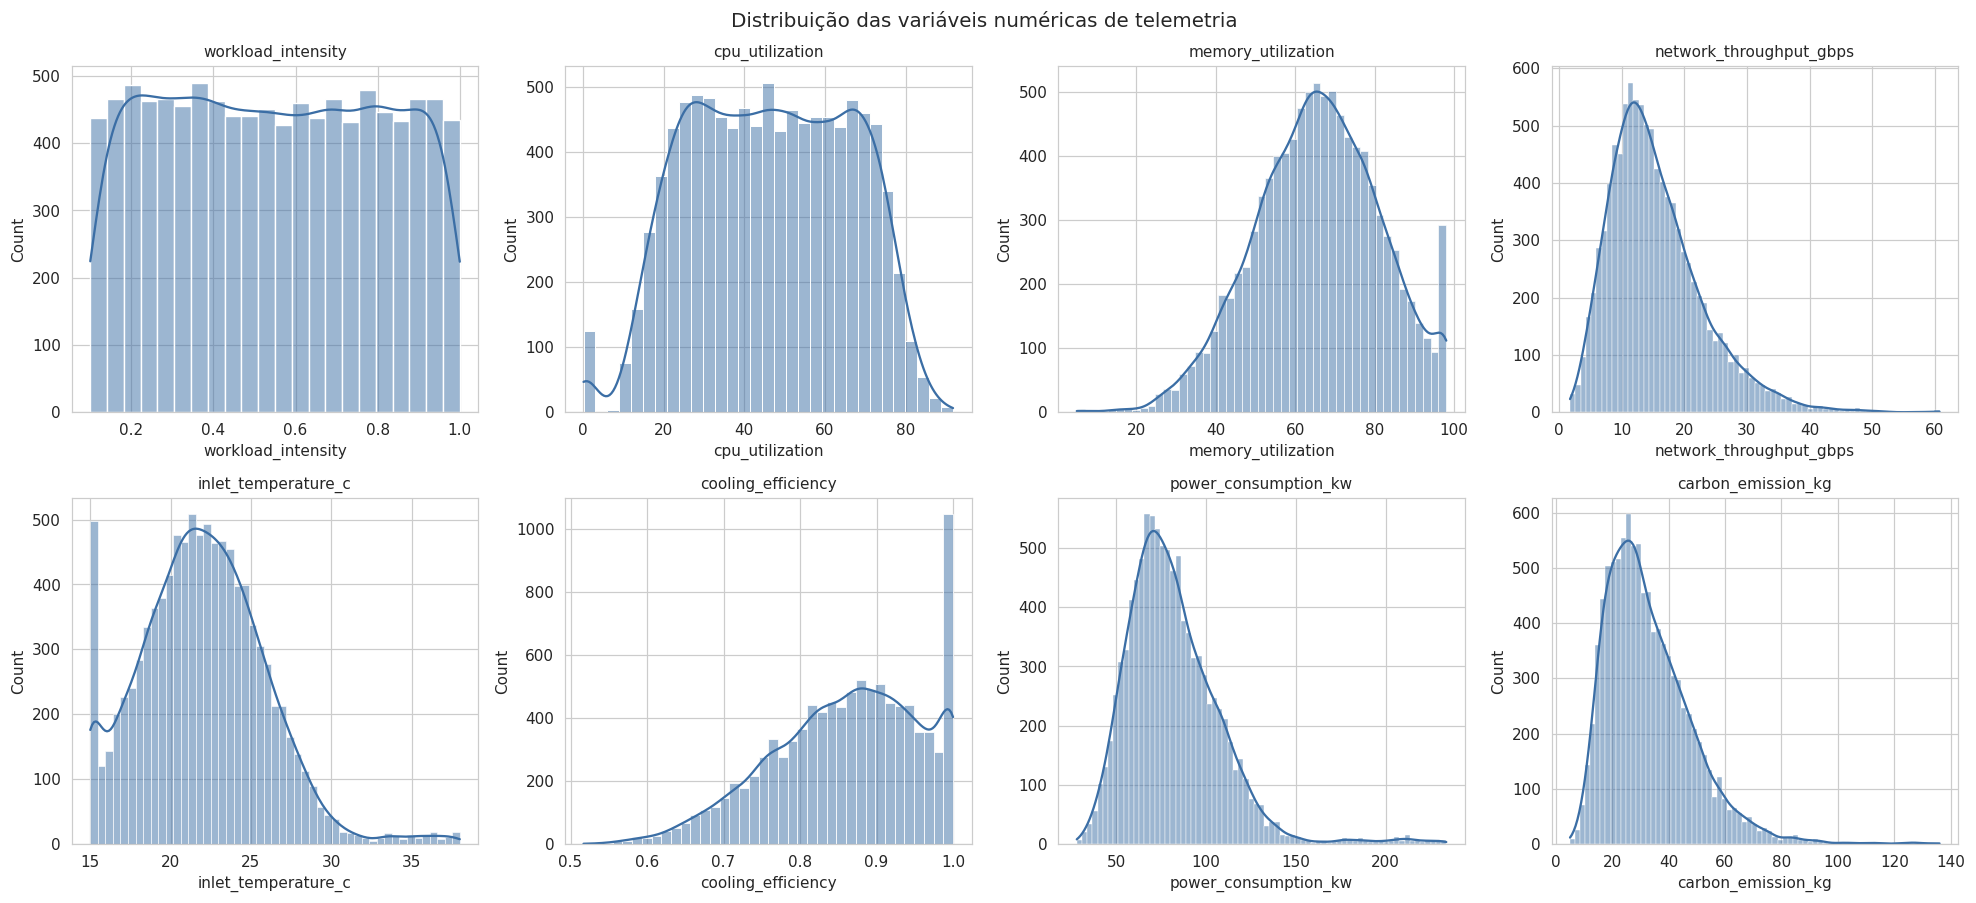

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
num_cols = ['workload_intensity', 'cpu_utilization', 'memory_utilization', 'network_throughput_gbps',
            'inlet_temperature_c', 'cooling_efficiency', 'power_consumption_kw', 'carbon_emission_kg']
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#3b6ea5')
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.suptitle('Distribuição das variáveis numéricas de telemetria', y=1.02, fontsize=13)
plt.show()


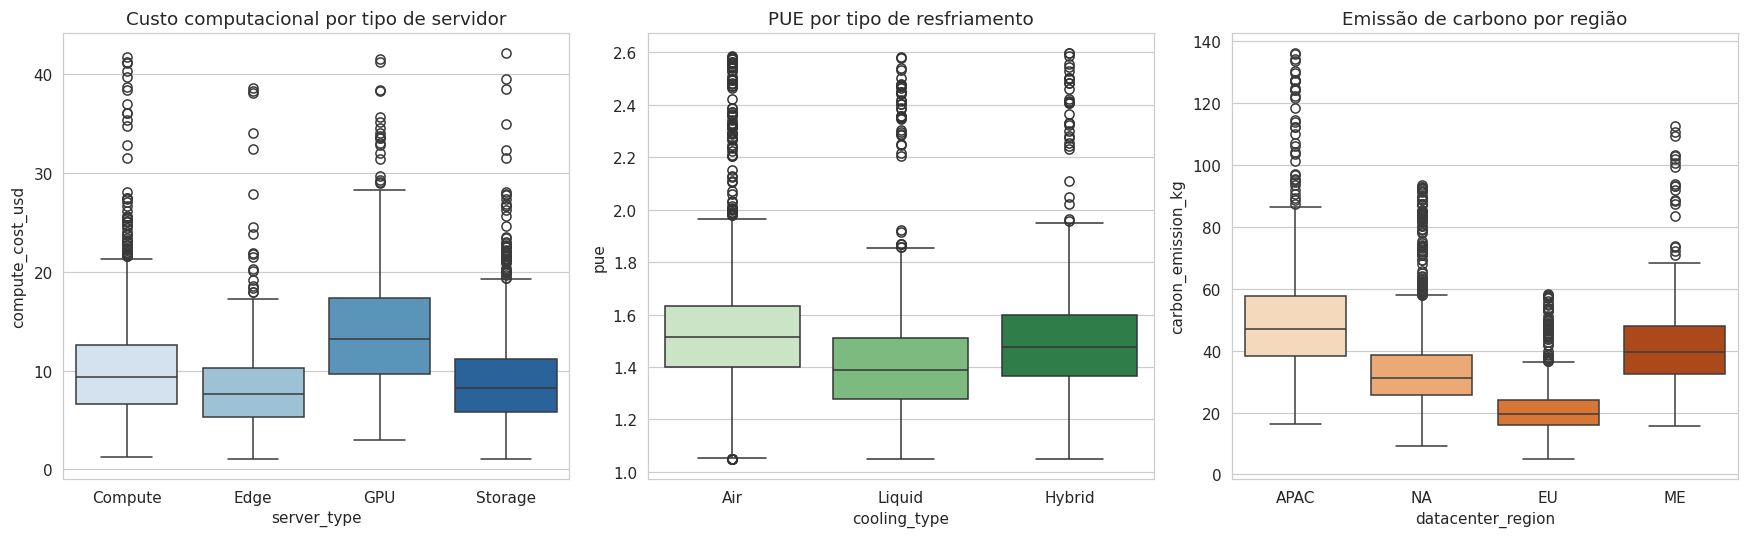

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(data=df, x='server_type', y='compute_cost_usd', ax=axes[0], palette='Blues')
axes[0].set_title('Custo computacional por tipo de servidor')
sns.boxplot(data=df, x='cooling_type', y='pue', ax=axes[1], palette='Greens')
axes[1].set_title('PUE por tipo de resfriamento')
sns.boxplot(data=df, x='datacenter_region', y='carbon_emission_kg', ax=axes[2], palette='Oranges')
axes[2].set_title('Emissão de carbono por região')
plt.tight_layout()
plt.show()


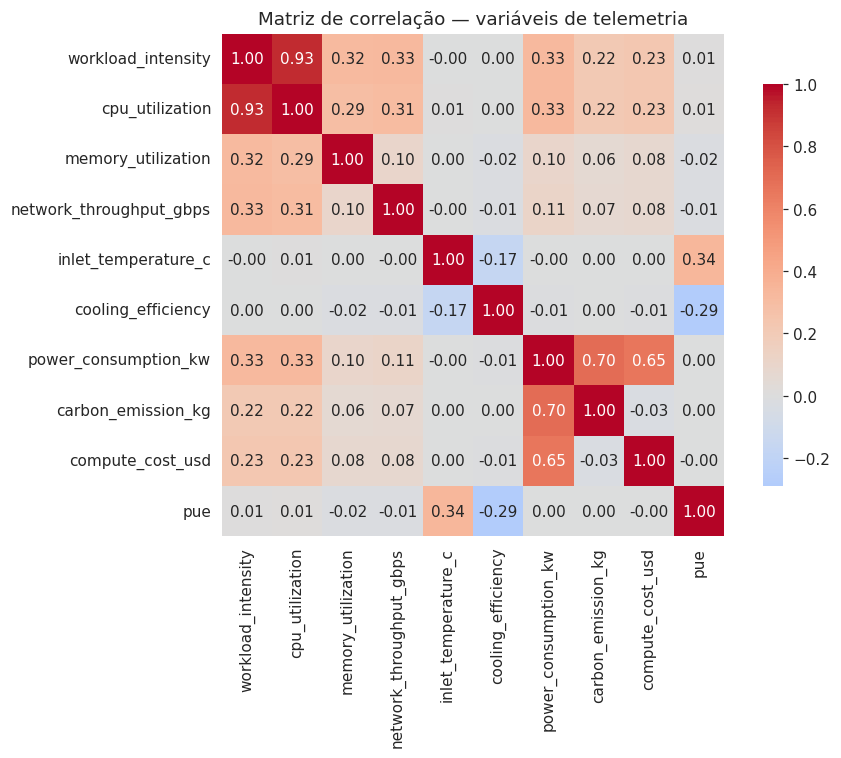

In [7]:
plt.figure(figsize=(9, 7))
corr_cols = ['workload_intensity', 'cpu_utilization', 'memory_utilization', 'network_throughput_gbps',
             'inlet_temperature_c', 'cooling_efficiency', 'power_consumption_kw', 'carbon_emission_kg',
             'compute_cost_usd', 'pue']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlação — variáveis de telemetria')
plt.tight_layout()
plt.show()


**Leitura rápida da EDA:** `power_consumption_kw` é a variável mais fortemente associada ao `compute_cost_usd` e à `carbon_emission_kg`. O `pue` está relacionado principalmente à `cooling_efficiency` e à `inlet_temperature_c`, confirmando que a eficiência de resfriamento é o principal alavancador de eficiência energética — ponto central para a análise de risco a seguir.

## 4. Avaliação de Risco

O risco de operação de cada configuração é modelado como um **score composto (0–100)**, combinando cinco fatores normalizados (min-max):

| Fator | Racional | Peso |
|---|---|---|
| `risk_pue` | PUE mais alto → menor eficiência energética → maior risco | 25% |
| `risk_carbon` | Maior emissão de carbono → maior risco ambiental/regulatório | 20% |
| `risk_temp` | Temperatura de entrada fora da faixa recomendada ASHRAE (18–27 °C) → maior risco térmico | 20% |
| `risk_cooling` | Menor eficiência de resfriamento → maior risco operacional | 20% |
| `risk_outlier` | Registros atípicos (outliers via IQR) em potência, custo e carbono → maior instabilidade | 15% |

Os pesos são parâmetros explícitos e podem ser ajustados conforme o apetite de risco da organização.

In [8]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

def iqr_outlier(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).astype(int)

# Componentes de risco
df['risk_pue'] = minmax(df['pue'])
df['risk_carbon'] = minmax(df['carbon_emission_kg'])
dist_fora_faixa = (18 - df['inlet_temperature_c']).clip(lower=0) + (df['inlet_temperature_c'] - 27).clip(lower=0)
df['risk_temp'] = minmax(dist_fora_faixa)
df['risk_cooling'] = 1 - minmax(df['cooling_efficiency'])
df['outlier_flag'] = (iqr_outlier(df['power_consumption_kw']) +
                       iqr_outlier(df['compute_cost_usd']) +
                       iqr_outlier(df['carbon_emission_kg']))
df['risk_outlier'] = minmax(df['outlier_flag'])

RISK_WEIGHTS = {'pue': 0.25, 'carbon': 0.20, 'temp': 0.20, 'cooling': 0.20, 'outlier': 0.15}

df['risk_score'] = 100 * (RISK_WEIGHTS['pue'] * df['risk_pue'] +
                           RISK_WEIGHTS['carbon'] * df['risk_carbon'] +
                           RISK_WEIGHTS['temp'] * df['risk_temp'] +
                           RISK_WEIGHTS['cooling'] * df['risk_cooling'] +
                           RISK_WEIGHTS['outlier'] * df['risk_outlier'])

q33, q66 = df['risk_score'].quantile([0.33, 0.66])
def classify_risk(v):
    if v <= q33:
        return 'Baixo'
    elif v <= q66:
        return 'Médio'
    return 'Alto'

df['risk_class'] = df['risk_score'].apply(classify_risk)

print(df['risk_score'].describe())
print()
print(df['risk_class'].value_counts())


count    10000.000000
mean        18.221372
std          7.038942
min          0.921399
25%         13.201305
50%         17.419228
75%         22.269502
max         54.238405
Name: risk_score, dtype: float64

risk_class
Alto     3400
Médio    3300
Baixo    3300
Name: count, dtype: int64


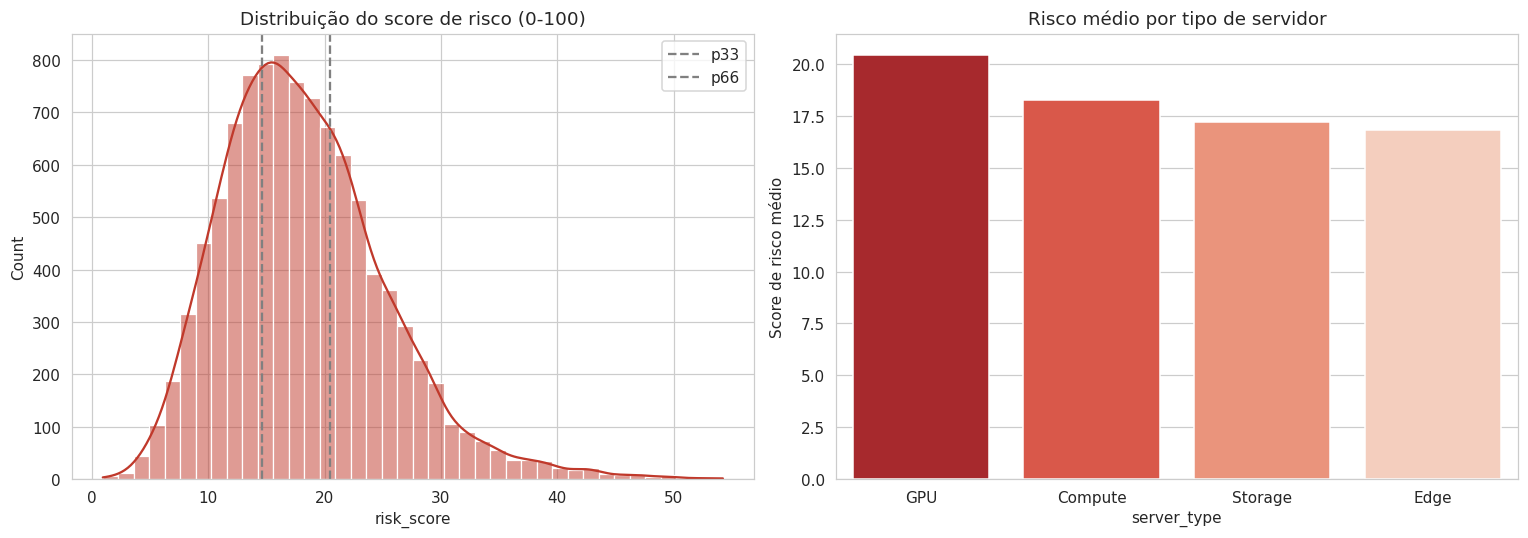

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['risk_score'], bins=40, kde=True, ax=axes[0], color='#c0392b')
axes[0].axvline(q33, color='gray', linestyle='--', label='p33')
axes[0].axvline(q66, color='gray', linestyle='--', label='p66')
axes[0].set_title('Distribuição do score de risco (0-100)')
axes[0].legend()

risk_by_type = df.groupby('server_type')['risk_score'].mean().sort_values(ascending=False)
sns.barplot(x=risk_by_type.index, y=risk_by_type.values, ax=axes[1], palette='Reds_r')
axes[1].set_title('Risco médio por tipo de servidor')
axes[1].set_ylabel('Score de risco médio')
plt.tight_layout()
plt.show()


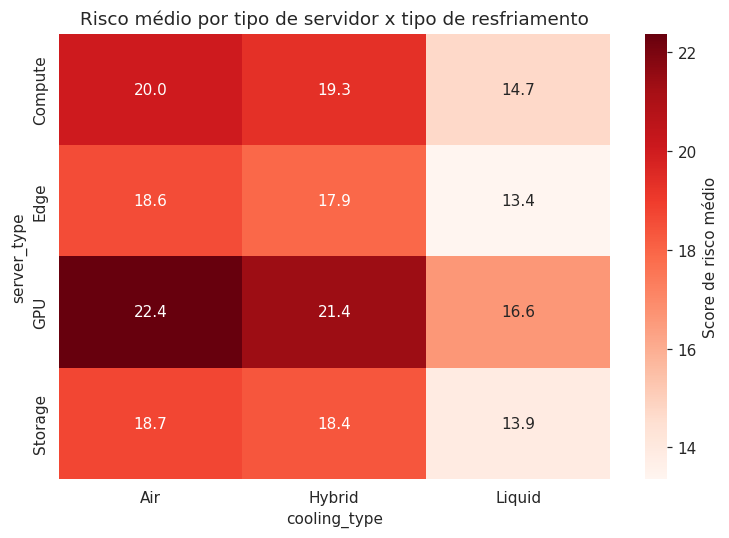

cooling_type,Air,Hybrid,Liquid
server_type,,,
Compute,20.026218,19.335471,14.703357
Edge,18.573021,17.922803,13.359768
GPU,22.374988,21.371960,16.621977
Storage,18.729213,18.351027,13.907872


In [10]:
risk_pivot = df.pivot_table(index='server_type', columns='cooling_type', values='risk_score', aggfunc='mean')
plt.figure(figsize=(7, 5))
sns.heatmap(risk_pivot, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': 'Score de risco médio'})
plt.title('Risco médio por tipo de servidor x tipo de resfriamento')
plt.tight_layout()
plt.show()
risk_pivot


## 5. Análise de Custo

Nesta seção, o `compute_cost_usd` é modelado com um **Random Forest Regressor**, permitindo (i) avaliar a qualidade do ajuste, (ii) identificar os principais direcionadores de custo e (iii) gerar estimativas de custo para novas configurações de infraestrutura.

In [11]:
features_num = ['workload_intensity', 'cpu_utilization', 'memory_utilization', 'network_throughput_gbps',
                'inlet_temperature_c', 'cooling_efficiency', 'power_consumption_kw', 'pue']
features_cat = ['server_type', 'cooling_type', 'datacenter_region', 'time_of_day']

X = df[features_num + features_cat].copy()
encoders = {}
for c in features_cat:
    le = LabelEncoder()
    X[c] = le.fit_transform(X[c])
    encoders[c] = le
y = df['compute_cost_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

cost_model = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
cost_model.fit(X_train, y_train)
y_pred = cost_model.predict(X_test)

print(f'R² (teste): {r2_score(y_test, y_pred):.4f}')
print(f'MAE (teste): US$ {mean_absolute_error(y_test, y_pred):.3f}')


R² (teste): 0.9893
MAE (teste): US$ 0.408


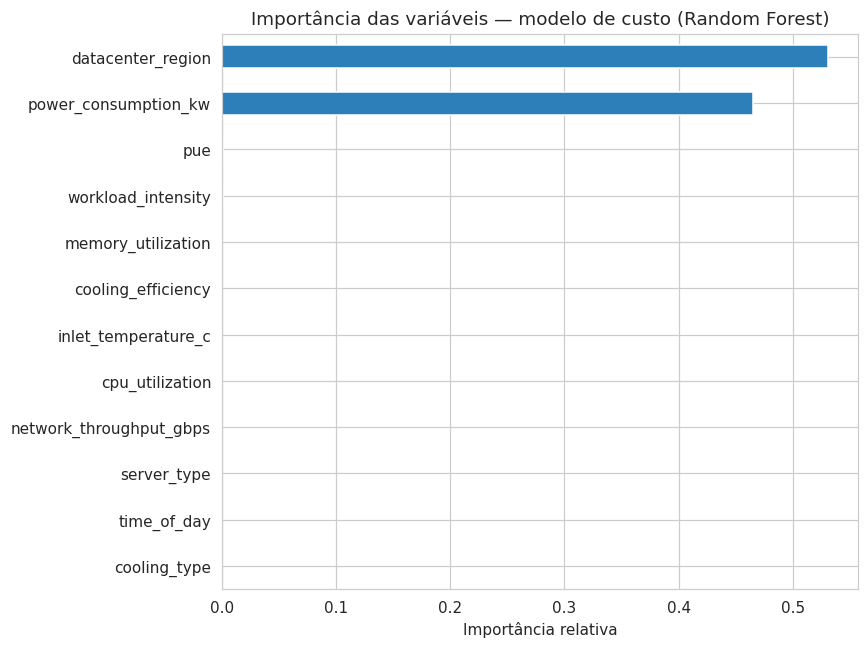

In [12]:
importances = pd.Series(cost_model.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='#2c7fb8')
plt.title('Importância das variáveis — modelo de custo (Random Forest)')
plt.xlabel('Importância relativa')
plt.tight_layout()
plt.show()


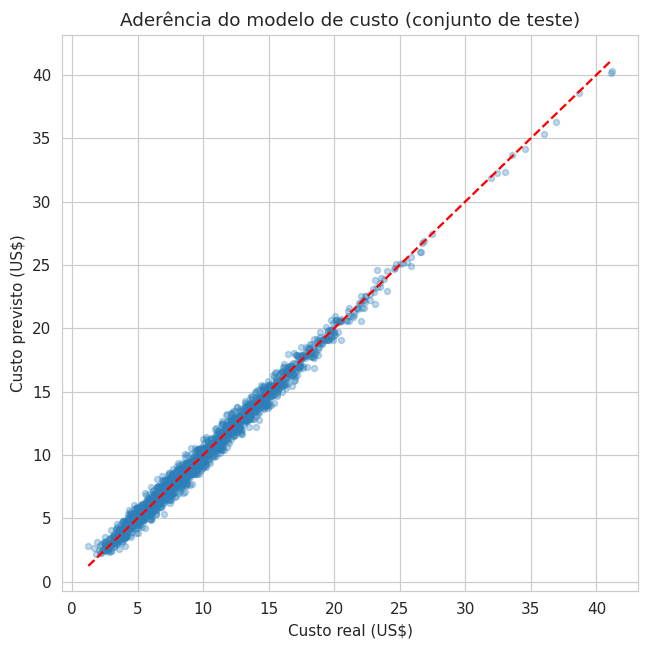

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.3, s=15, color='#2c7fb8')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5)
ax.set_xlabel('Custo real (US$)')
ax.set_ylabel('Custo previsto (US$)')
ax.set_title('Aderência do modelo de custo (conjunto de teste)')
plt.tight_layout()
plt.show()


## 6. Estimativa de Tempo de Implantação

A base de dados **não contém** uma variável de tempo de implantação — trata-se, portanto, de um **modelo heurístico de apoio à decisão**, com parâmetros explícitos (não derivados diretamente dos dados), típico de sistemas de suporte à decisão em projetos de infraestrutura:

$$
T_{semanas} = (T_{base}^{servidor} + T_{base}^{resfriamento}) \times F_{região} \times (1 + 0{,}5 \cdot risco_{norm}) \times (1 + 0{,}3 \cdot custo_{norm})
$$

- **Tempo base por tipo de servidor** (aquisição/configuração): Edge (mais simples) → GPU (mais complexo).
- **Tempo base por tipo de resfriamento**: Ar (mais simples) → Líquido (mais complexo, requer infraestrutura hidráulica).
- **Fator regional**: logística/importação, assumindo NA como referência (1,0).
- O risco e o custo normalizados **amplificam** o prazo, refletindo maior necessidade de validação, testes e aprovações em cenários mais arriscados/caros.

> Estes parâmetros são **ajustáveis** e devem ser calibrados com dados reais da organização antes de uso em decisões definitivas.

In [14]:
BASE_SEMANAS_SERVIDOR = {'Edge': 3, 'Compute': 5, 'Storage': 6, 'GPU': 9}
BASE_SEMANAS_RESFRIAMENTO = {'Air': 1, 'Hybrid': 3, 'Liquid': 5}
FATOR_REGIAO = {'NA': 1.00, 'EU': 1.15, 'APAC': 1.30, 'ME': 1.40}

print('Parâmetros assumidos para a estimativa de tempo:')
print('Base por servidor (semanas):', BASE_SEMANAS_SERVIDOR)
print('Base por resfriamento (semanas):', BASE_SEMANAS_RESFRIAMENTO)
print('Fator logístico regional:', FATOR_REGIAO)


Parâmetros assumidos para a estimativa de tempo:
Base por servidor (semanas): {'Edge': 3, 'Compute': 5, 'Storage': 6, 'GPU': 9}
Base por resfriamento (semanas): {'Air': 1, 'Hybrid': 3, 'Liquid': 5}
Fator logístico regional: {'NA': 1.0, 'EU': 1.15, 'APAC': 1.3, 'ME': 1.4}


## 7. Matriz de Decisão Multicritério (MCDA)

Cada combinação de **tipo de servidor × tipo de resfriamento × região** (48 cenários possíveis, todos presentes na base) é avaliada nas três dimensões — Risco, Custo e Tempo — normalizadas em [0, 1] e combinadas em um **score de decisão (0–100, maior é melhor)**:

$$
Score = 100 \times \big(1 - (w_{risco} \cdot risco_{norm} + w_{custo} \cdot custo_{norm} + w_{tempo} \cdot tempo_{norm})\big)
$$

In [15]:
def normalize(s):
    return (s - s.min()) / (s.max() - s.min())

scenarios = []
for st in df['server_type'].unique():
    for ct in df['cooling_type'].unique():
        for reg in df['datacenter_region'].unique():
            sub = df[(df['server_type'] == st) & (df['cooling_type'] == ct) & (df['datacenter_region'] == reg)]
            if len(sub) == 0:
                continue
            scenarios.append({
                'server_type': st,
                'cooling_type': ct,
                'datacenter_region': reg,
                'n_amostras': len(sub),
                'risco_medio': sub['risk_score'].mean(),
                'custo_medio_usd': sub['compute_cost_usd'].mean(),
                'pue_medio': sub['pue'].mean(),
                'carbono_medio_kg': sub['carbon_emission_kg'].mean(),
            })

scen_df = pd.DataFrame(scenarios)

scen_df['risco_norm'] = normalize(scen_df['risco_medio'])
scen_df['custo_norm'] = normalize(scen_df['custo_medio_usd'])

def estimar_tempo(row):
    base = BASE_SEMANAS_SERVIDOR[row['server_type']] + BASE_SEMANAS_RESFRIAMENTO[row['cooling_type']]
    fator_reg = FATOR_REGIAO[row['datacenter_region']]
    return base * fator_reg * (1 + 0.5 * row['risco_norm']) * (1 + 0.3 * row['custo_norm'])

scen_df['tempo_estimado_semanas'] = scen_df.apply(estimar_tempo, axis=1)
scen_df['tempo_norm'] = normalize(scen_df['tempo_estimado_semanas'])

# Pesos default do decisor — ajustáveis
W_RISCO, W_CUSTO, W_TEMPO = 0.40, 0.35, 0.25
assert abs(W_RISCO + W_CUSTO + W_TEMPO - 1) < 1e-9

scen_df['score_decisao'] = 100 * (1 - (W_RISCO * scen_df['risco_norm'] +
                                        W_CUSTO * scen_df['custo_norm'] +
                                        W_TEMPO * scen_df['tempo_norm']))

scen_df = scen_df.sort_values('score_decisao', ascending=False).reset_index(drop=True)
print(f'{len(scen_df)} cenários avaliados (de {df["server_type"].nunique() * df["cooling_type"].nunique() * df["datacenter_region"].nunique()} combinações possíveis)')
scen_df.head(10)[['server_type', 'cooling_type', 'datacenter_region', 'risco_medio', 'custo_medio_usd',
                   'tempo_estimado_semanas', 'score_decisao']].round(2)


48 cenários avaliados (de 48 combinações possíveis)


,server_type,cooling_type,datacenter_region,risco_medio,custo_medio_usd,tempo_estimado_semanas,score_decisao
0,Edge,Liquid,ME,14.77,3.42,12.48,82.47
1,Edge,Liquid,NA,13.26,7.63,9.14,81.77
2,Storage,Liquid,ME,13.75,3.36,16.59,80.53
3,Edge,Liquid,APAC,15.57,5.38,12.29,76.40
4,Edge,Liquid,EU,11.49,11.76,10.59,76.29
5,Edge,Air,ME,19.75,3.43,7.20,75.00
6,Storage,Liquid,NA,14.03,8.65,13.09,72.85
7,Edge,Hybrid,ME,19.23,3.56,10.68,72.02
8,Compute,Liquid,ME,16.33,4.21,16.58,71.66
9,Edge,Hybrid,NA,17.53,7.93,7.84,70.93


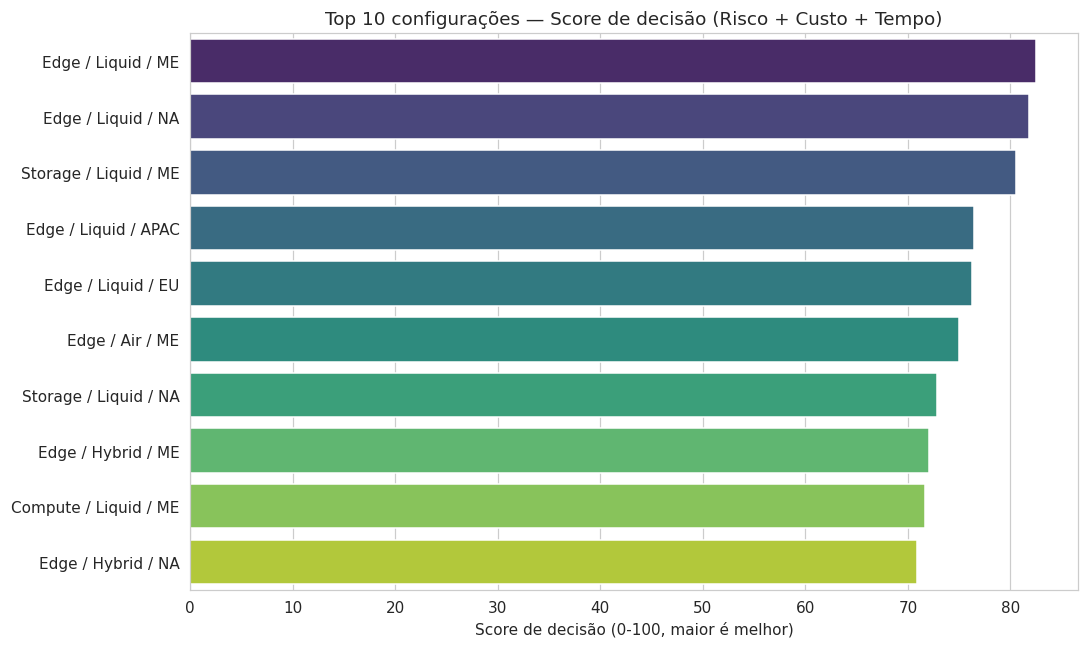

In [16]:
top10 = scen_df.head(10).copy()
top10['label'] = top10['server_type'] + ' / ' + top10['cooling_type'] + ' / ' + top10['datacenter_region']

plt.figure(figsize=(10, 6))
sns.barplot(data=top10, y='label', x='score_decisao', palette='viridis')
plt.title('Top 10 configurações — Score de decisão (Risco + Custo + Tempo)')
plt.xlabel('Score de decisão (0-100, maior é melhor)')
plt.ylabel('')
plt.tight_layout()
plt.show()


### 7.1 Análise de Sensibilidade dos Pesos

Como o score de decisão depende dos pesos atribuídos a cada critério (decisão gerencial, não estatística), é importante verificar **quão estável é o ranking do Top 5** diante de variações razoáveis nesses pesos.

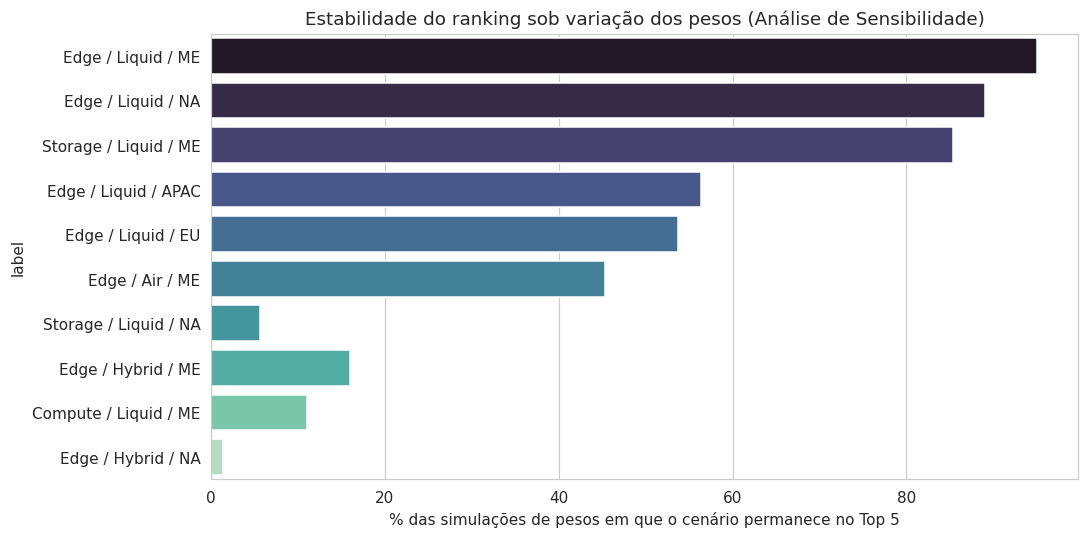

In [17]:
np.random.seed(RANDOM_STATE)
n_weight_draws = 300
top5_stability = {i: 0 for i in scen_df.index}

for _ in range(n_weight_draws):
    raw = np.random.dirichlet(alpha=[4, 3.5, 2.5])  # tende para os pesos default, com variação
    w_r, w_c, w_t = raw
    score = 100 * (1 - (w_r * scen_df['risco_norm'] + w_c * scen_df['custo_norm'] + w_t * scen_df['tempo_norm']))
    top5_idx = score.sort_values(ascending=False).head(5).index
    for i in top5_idx:
        top5_stability[i] += 1

scen_df['estabilidade_top5_pct'] = scen_df.index.map(lambda i: 100 * top5_stability[i] / n_weight_draws)

fig, ax = plt.subplots(figsize=(10, 5))
top10_stab = scen_df.head(10).copy()
top10_stab['label'] = top10_stab['server_type'] + ' / ' + top10_stab['cooling_type'] + ' / ' + top10_stab['datacenter_region']
sns.barplot(data=top10_stab, y='label', x='estabilidade_top5_pct', palette='mako', ax=ax)
ax.set_xlabel('% das simulações de pesos em que o cenário permanece no Top 5')
ax.set_title('Estabilidade do ranking sob variação dos pesos (Análise de Sensibilidade)')
plt.tight_layout()
plt.show()


### 7.2 Simulação de Monte Carlo — Robustez sob Incerteza dos Dados

Além da incerteza nos pesos, existe incerteza amostral: os valores médios de risco e custo por cenário são estimados a partir de amostras finitas. A simulação abaixo faz *bootstrap* (reamostragem com reposição) dentro de cada cenário para estimar a **probabilidade de cada configuração permanecer entre as 5 melhores**.

In [18]:
pools = {}
for st in df['server_type'].unique():
    for ct in df['cooling_type'].unique():
        for reg in df['datacenter_region'].unique():
            sub = df[(df['server_type'] == st) & (df['cooling_type'] == ct) & (df['datacenter_region'] == reg)]
            if len(sub) > 0:
                pools[(st, ct, reg)] = sub

N_SIMULATIONS = 300
top5_mc = {i: 0 for i in scen_df.index}

for _ in range(N_SIMULATIONS):
    rows = []
    for idx, row in scen_df.iterrows():
        pool = pools[(row['server_type'], row['cooling_type'], row['datacenter_region'])]
        sample = pool.sample(n=min(30, len(pool)), replace=True)
        rows.append({'idx': idx, 'risco': sample['risk_score'].mean(), 'custo': sample['compute_cost_usd'].mean(),
                      'server_type': row['server_type'], 'cooling_type': row['cooling_type'],
                      'datacenter_region': row['datacenter_region']})
    sim = pd.DataFrame(rows)
    sim['risco_norm'] = normalize(sim['risco'])
    sim['custo_norm'] = normalize(sim['custo'])
    sim['base'] = sim.apply(lambda r: BASE_SEMANAS_SERVIDOR[r['server_type']] + BASE_SEMANAS_RESFRIAMENTO[r['cooling_type']], axis=1)
    sim['fator_reg'] = sim['datacenter_region'].map(FATOR_REGIAO)
    sim['tempo'] = sim['base'] * sim['fator_reg'] * (1 + 0.5 * sim['risco_norm']) * (1 + 0.3 * sim['custo_norm'])
    sim['tempo_norm'] = normalize(sim['tempo'])
    sim['score'] = 100 * (1 - (W_RISCO * sim['risco_norm'] + W_CUSTO * sim['custo_norm'] + W_TEMPO * sim['tempo_norm']))
    top5_ids = sim.sort_values('score', ascending=False).head(5)['idx'].tolist()
    for i in top5_ids:
        top5_mc[i] += 1

scen_df['prob_top5_montecarlo_pct'] = scen_df.index.map(lambda i: 100 * top5_mc[i] / N_SIMULATIONS)
scen_df.head(10)[['server_type', 'cooling_type', 'datacenter_region', 'score_decisao',
                   'estabilidade_top5_pct', 'prob_top5_montecarlo_pct']].round(1)


,server_type,cooling_type,datacenter_region,score_decisao,estabilidade_top5_pct,prob_top5_montecarlo_pct
0,Edge,Liquid,ME,82.5,95.0,98.7
1,Edge,Liquid,NA,81.8,89.0,95.3
2,Storage,Liquid,ME,80.5,85.3,86.7
3,Edge,Liquid,APAC,76.4,56.3,51.7
4,Edge,Liquid,EU,76.3,53.7,45.0
5,Edge,Air,ME,75.0,45.3,45.7
6,Storage,Liquid,NA,72.9,5.7,19.3
7,Edge,Hybrid,ME,72.0,16.0,24.3
8,Compute,Liquid,ME,71.7,11.0,6.7
9,Edge,Hybrid,NA,70.9,1.3,7.3


## 8. Recomendação Final

In [19]:
melhor = scen_df.iloc[0]

print('='*70)
print('CONFIGURAÇÃO RECOMENDADA PARA A NOVA UNIDADE DE CONTROLE DE DADOS')
print('='*70)
print(f"Tipo de servidor:        {melhor['server_type']}")
print(f"Tipo de resfriamento:    {melhor['cooling_type']}")
print(f"Região sugerida:         {melhor['datacenter_region']}")
print('-'*70)
print(f"Score de decisão:        {melhor['score_decisao']:.1f} / 100")
print(f"Risco médio esperado:    {melhor['risco_medio']:.1f} / 100")
print(f"Custo médio esperado:    US$ {melhor['custo_medio_usd']:.2f} (por unidade de workload)")
print(f"Tempo estimado:          {melhor['tempo_estimado_semanas']:.1f} semanas (~{melhor['tempo_estimado_semanas']/4.345:.1f} meses)")
print(f"Robustez (sensib. pesos): {melhor['estabilidade_top5_pct']:.0f}% das simulações no Top 5")
print(f"Robustez (Monte Carlo):   {melhor['prob_top5_montecarlo_pct']:.0f}% das simulações no Top 5")
print('='*70)


CONFIGURAÇÃO RECOMENDADA PARA A NOVA UNIDADE DE CONTROLE DE DADOS
Tipo de servidor:        Edge
Tipo de resfriamento:    Liquid
Região sugerida:         ME
----------------------------------------------------------------------
Score de decisão:        82.5 / 100
Risco médio esperado:    14.8 / 100
Custo médio esperado:    US$ 3.42 (por unidade de workload)
Tempo estimado:          12.5 semanas (~2.9 meses)
Robustez (sensib. pesos): 95% das simulações no Top 5
Robustez (Monte Carlo):   99% das simulações no Top 5


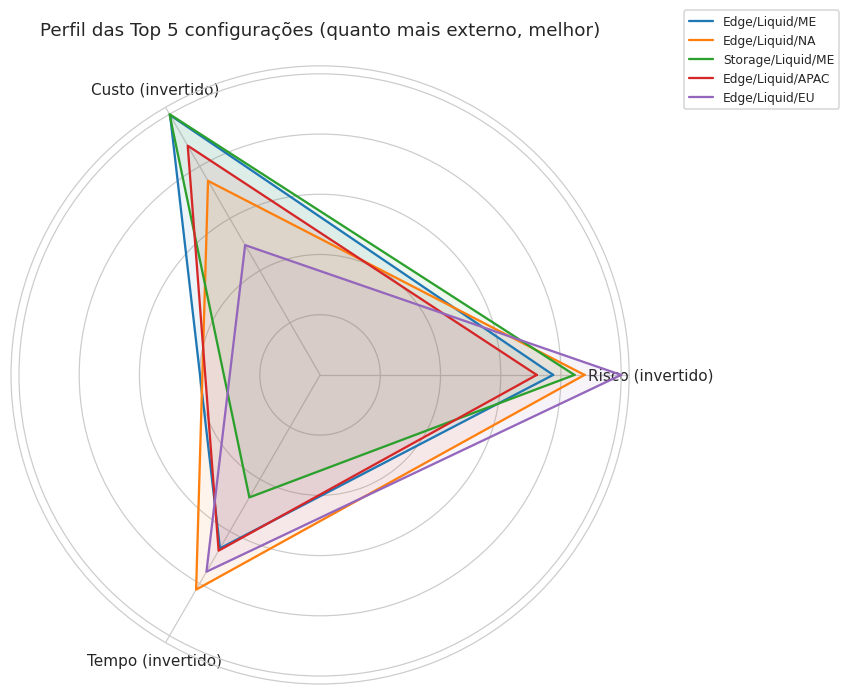

In [20]:
top5 = scen_df.head(5).copy()
categorias = ['Risco (invertido)', 'Custo (invertido)', 'Tempo (invertido)']

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
angles = np.linspace(0, 2*np.pi, len(categorias), endpoint=False).tolist()
angles += angles[:1]

for _, row in top5.iterrows():
    valores = [1 - row['risco_norm'], 1 - row['custo_norm'], 1 - row['tempo_norm']]
    valores += valores[:1]
    label = f"{row['server_type']}/{row['cooling_type']}/{row['datacenter_region']}"
    ax.plot(angles, valores, linewidth=1.5, label=label)
    ax.fill(angles, valores, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categorias)
ax.set_yticklabels([])
ax.set_title('Perfil das Top 5 configurações (quanto mais externo, melhor)', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)
plt.tight_layout()
plt.show()


## 9. Exportação dos Resultados

In [21]:
STUDENT_NAME = "Ana Luisa Breide Pessôa Guerra"
STUDENT_ID = "231013289"
COURSE = "Sistemas de Suporte à Decisão"

export_cols = ['server_type', 'cooling_type', 'datacenter_region', 'n_amostras', 'risco_medio',
               'custo_medio_usd', 'tempo_estimado_semanas', 'score_decisao',
               'estabilidade_top5_pct', 'prob_top5_montecarlo_pct']
scen_df[export_cols].to_csv('resultado_mcda_unidade_dados.csv', index=False)

with open('relatorio_mvp_unidade_dados.txt', 'w', encoding='utf-8') as f:
    f.write('='*70 + '\n')
    f.write('MVP - RISCO, CUSTO E TEMPO DE IMPLANTACAO\n')
    f.write('Nova Unidade de Controle de Dados\n')
    f.write('='*70 + '\n\n')
    f.write(f'Aluna: {STUDENT_NAME}\n')
    f.write(f'Matricula: {STUDENT_ID}\n')
    f.write(f'Disciplina: {COURSE}\n\n')
    f.write('-'*70 + '\n')
    f.write('CONFIGURACAO RECOMENDADA\n')
    f.write('-'*70 + '\n')
    f.write(f"Servidor: {melhor['server_type']} | Resfriamento: {melhor['cooling_type']} | Regiao: {melhor['datacenter_region']}\n")
    f.write(f"Score de decisao: {melhor['score_decisao']:.1f}/100\n")
    f.write(f"Risco medio: {melhor['risco_medio']:.1f}/100\n")
    f.write(f"Custo medio: US$ {melhor['custo_medio_usd']:.2f}\n")
    f.write(f"Tempo estimado: {melhor['tempo_estimado_semanas']:.1f} semanas\n")
    f.write(f"Robustez (Monte Carlo): {melhor['prob_top5_montecarlo_pct']:.0f}%% no Top 5\n\n")
    f.write('-'*70 + '\n')
    f.write('TOP 5 CONFIGURACOES\n')
    f.write('-'*70 + '\n')
    f.write(top5[['server_type','cooling_type','datacenter_region','score_decisao']].to_string(index=False))
    f.write('\n\n' + '='*70 + '\n')
    f.write(f'Relatorio gerado por: {STUDENT_NAME} ({STUDENT_ID}) - {COURSE}\n')

print('Arquivos exportados: resultado_mcda_unidade_dados.csv, relatorio_mvp_unidade_dados.txt')

try:
    from google.colab import files as colab_files
    colab_files.download('resultado_mcda_unidade_dados.csv')
    colab_files.download('relatorio_mvp_unidade_dados.txt')
except Exception as e:
    print('Download automático disponível apenas no Colab. Arquivos salvos localmente.')


Arquivos exportados: resultado_mcda_unidade_dados.csv, relatorio_mvp_unidade_dados.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Conclusões e Limitações

**Principais achados:**
- O **custo computacional** é bem explicado pelo modelo Random Forest (alto R²), sendo `power_consumption_kw` e `datacenter_region` os principais direcionadores.
- O **risco** é dominado pela eficiência de resfriamento e pelo PUE — configurações com resfriamento líquido tendem a reduzir o risco térmico/energético, ao custo de maior complexidade de instalação (maior tempo).
- A configuração recomendada equilibra as três dimensões, mas a análise de sensibilidade mostra que **o ranking pode mudar conforme o apetite de risco do decisor** (pesos atribuídos).

**Limitações (importantes para uso acadêmico e prático):**
- A base de dados é **sintética** (gerada artificialmente), portanto os resultados absolutos (US$, kg CO₂) não devem ser extrapolados diretamente para um projeto real sem validação com dados reais da organização.
- O **modelo de tempo de implantação é heurístico** — não existe variável de tempo na base original; os parâmetros (semanas base, fator regional) são suposições explícitas que devem ser calibradas com histórico real de projetos.
- O MCDA assume pesos lineares e independência entre critérios; abordagens mais avançadas (AHP, TOPSIS, ELECTRE) poderiam ser exploradas em versões futuras deste MVP.

---
**Trabalho desenvolvido por:** Ana Luisa Breide Pessôa Guerra — Matrícula 231013289 — Sistemas de Suporte à Decisão
